# 01 · Análisis Exploratorio de Datos (EDA)

**Proyecto Final — Machine Learning y Deep Learning**

Predicción de **cancelaciones de reservas hoteleras** (`is_canceled`, clasificación binaria).

Este notebook documenta el análisis exploratorio que ha guiado las decisiones de preprocesado y modelado implementadas en el paquete `src/`. El dataset contiene ~119 000 reservas de un *City Hotel* y un *Resort Hotel* (Portugal, 2015–2017).

> Las conclusiones de este EDA se traducen directamente en el código de `src/data_loader.py` y `src/preprocessing.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from src import config
from src.data_loader import load_raw_data


## 1. Carga y vista general de los datos

In [2]:
df = load_raw_data()
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Tipos de dato y memoria
resumen = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unicos': df.nunique(),
    'n_nulos': df.isna().sum(),
})
resumen

,dtype,n_unicos,n_nulos
hotel,str,2,0
is_canceled,int64,2,0
lead_time,int64,479,0
arrival_date_year,int64,3,0
arrival_date_month,str,12,0
arrival_date_week_number,int64,53,0
arrival_date_day_of_month,int64,31,0
stays_in_weekend_nights,int64,17,0
stays_in_week_nights,int64,35,0
adults,int64,14,0


## 2. Variable objetivo: `is_canceled`

Comprobamos el balance de clases, clave para elegir métrica y estrategia de validación.

Conteo:
 is_canceled
0    75166
1    44224
Name: count, dtype: int64

Proporción:
 is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


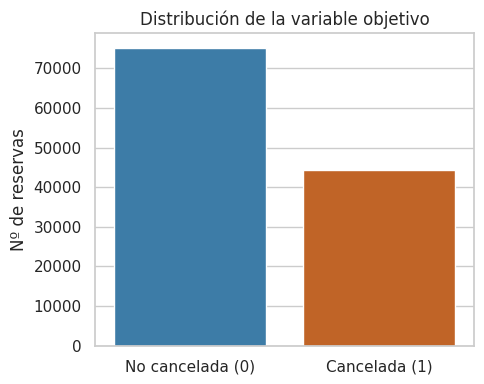

In [4]:
conteo = df['is_canceled'].value_counts().sort_index()
prop = df['is_canceled'].value_counts(normalize=True).sort_index()
print('Conteo:\n', conteo)
print('\nProporción:\n', prop.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='is_canceled', data=df, ax=ax, palette=['#2c7fb8', '#d95f0e'])
ax.set_xticklabels(['No cancelada (0)', 'Cancelada (1)'])
ax.set_title('Distribución de la variable objetivo')
ax.set_xlabel(''); ax.set_ylabel('Nº de reservas')
plt.tight_layout(); plt.show()

**Observación.** Alrededor del **37 % de las reservas se cancelan**. Es un desbalance moderado: usamos partición **estratificada** y elegimos **ROC-AUC** (independiente del umbral y robusta al desbalance) como métrica principal, reportando además F1 y recall por su interés de negocio.

## 3. Valores ausentes

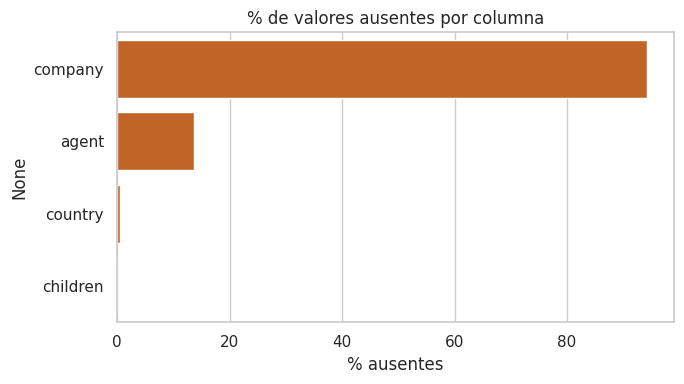

company     94.31
agent       13.69
country      0.41
children     0.00
dtype: float64

In [5]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=missing.values, y=missing.index, ax=ax, color='#d95f0e')
ax.set_title('% de valores ausentes por columna')
ax.set_xlabel('% ausentes'); plt.tight_layout(); plt.show()
missing.round(2)

**Decisiones.** `company` está ausente en ~**94 %** de las filas → se **descarta**. `agent` (~14 %) se trata como **categoría** marcando los ausentes como `"Unknown"`. `country` (~0.4 %) y `children` (residual) se **imputan**.

## 4. Fuga de información (*data leakage*)

Las columnas `reservation_status` y `reservation_status_date` describen el **desenlace** de la reserva. Lo comprobamos:

In [6]:
pd.crosstab(df['reservation_status'], df['is_canceled'])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


**Crítico.** `reservation_status == 'Canceled'` coincide exactamente con `is_canceled == 1` (y `No-Show` también cuenta como cancelación). Incluir estas columnas daría una precisión artificial de ~100 %. Por eso `src/config.py` las define en `LEAKAGE_COLUMNS` y se **eliminan siempre**.

## 5. Variables numéricas

In [7]:
num = [c for c in config.NUMERIC_COLUMNS if c in df.columns]
df[num].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0
is_repeated_guest,119390.0,0.03,0.18,0.00,0.00,0.00,0.0,1.0


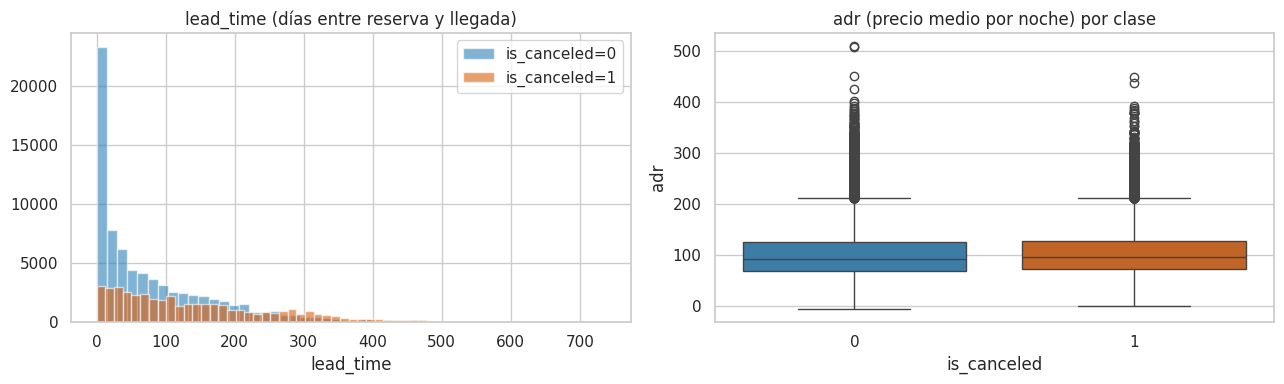

In [8]:
# Distribución de lead_time según cancelación
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cls, color in zip([0, 1], ['#2c7fb8', '#d95f0e']):
    sub = df[df['is_canceled'] == cls]['lead_time']
    axes[0].hist(sub, bins=50, alpha=0.6, label=f'is_canceled={cls}', color=color)
axes[0].set_title('lead_time (días entre reserva y llegada)')
axes[0].set_xlabel('lead_time'); axes[0].legend()

sns.boxplot(x='is_canceled', y='adr', data=df[df['adr'] < 1000], ax=axes[1],
            palette=['#2c7fb8', '#d95f0e'])
axes[1].set_title('adr (precio medio por noche) por clase')
plt.tight_layout(); plt.show()

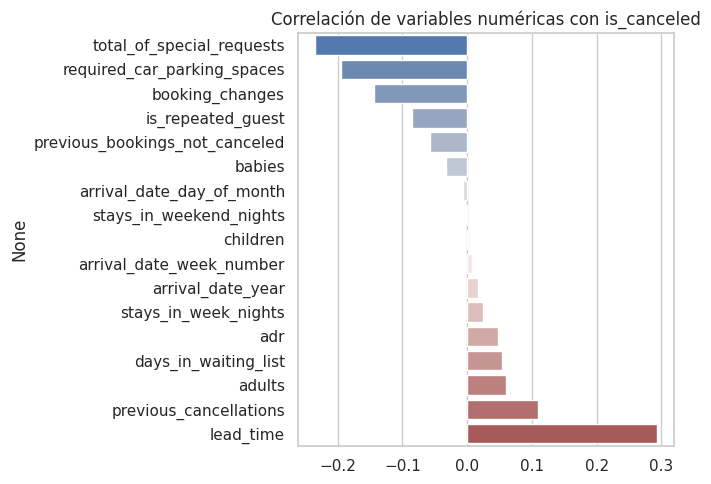

In [9]:
# Correlación de las numéricas con el target
corr = df[num + ['is_canceled']].corr()['is_canceled'].drop('is_canceled')
corr = corr.sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=corr.values, y=corr.index, ax=ax, palette='vlag')
ax.set_title('Correlación de variables numéricas con is_canceled')
plt.tight_layout(); plt.show()

**Insight.** `lead_time` correlaciona positivamente con la cancelación (reservar con mucha antelación → más probabilidad de cancelar), mientras que `total_of_special_requests` y `required_car_parking_spaces` correlacionan negativamente (clientes más comprometidos).

## 6. Variables categóricas y tasa de cancelación

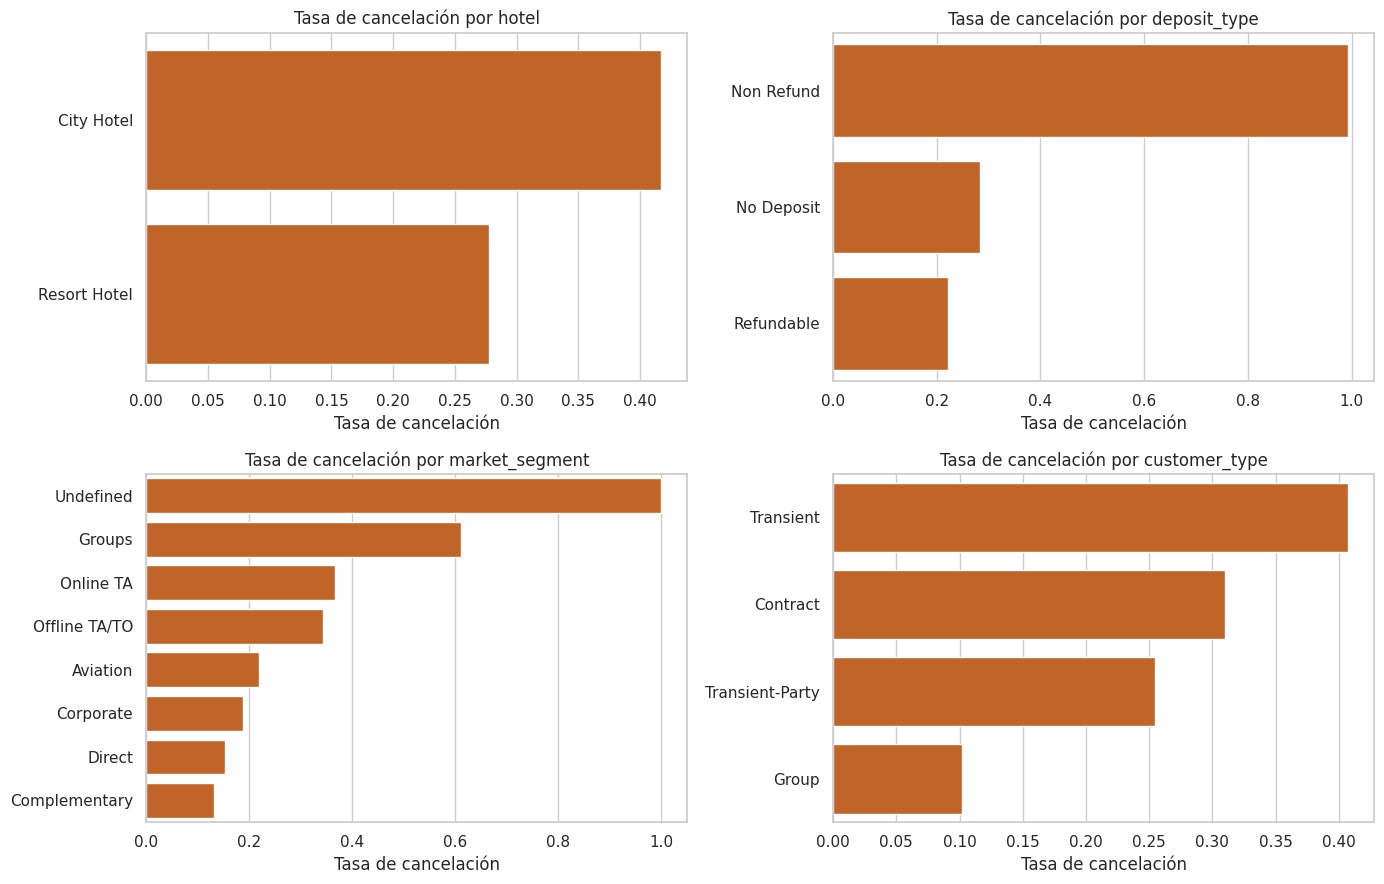

In [10]:
def tasa_cancelacion(col, ax):
    tasa = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    sns.barplot(x=tasa.values, y=tasa.index, ax=ax, color='#d95f0e')
    ax.set_title(f'Tasa de cancelación por {col}')
    ax.set_xlabel('Tasa de cancelación'); ax.set_ylabel('')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for col, ax in zip(['hotel', 'deposit_type', 'market_segment', 'customer_type'], axes.ravel()):
    tasa_cancelacion(col, ax)
plt.tight_layout(); plt.show()

**Insights clave.**
- `deposit_type == 'Non Refund'` presenta una tasa de cancelación altísima (~99 %): variable muy predictiva.
- El *City Hotel* se cancela más que el *Resort Hotel*.
- Los segmentos `Groups` y `Offline TA/TO` cancelan más que `Direct` o `Corporate`.
- El tipo de cliente `Transient` cancela más que `Contract`/`Group`.

## 7. Conclusiones del EDA → decisiones de modelado

| Hallazgo | Decisión en el código |
|---|---|
| `reservation_status*` filtran el target | Eliminar (`LEAKAGE_COLUMNS`) |
| `company` ~94 % nulos | Eliminar (`DROP_COLUMNS`) |
| `agent` es un ID con nulos | Tratar como categórica, nulos → `Unknown` |
| Nulos en `country`, `children` | Imputar (moda/constante y mediana) |
| Variables en escalas muy distintas | `StandardScaler` (numéricas) |
| Categóricas de alta cardinalidad (`country`, `agent`) | `OneHotEncoder` con `max_categories` |
| Clases desbalanceadas (~37 %) | Partición **estratificada** + métrica **ROC-AUC** |
| Reservas con 0 huéspedes | Eliminar (registros inconsistentes) |

Estas decisiones están implementadas en `src/data_loader.py` y `src/preprocessing.py`.